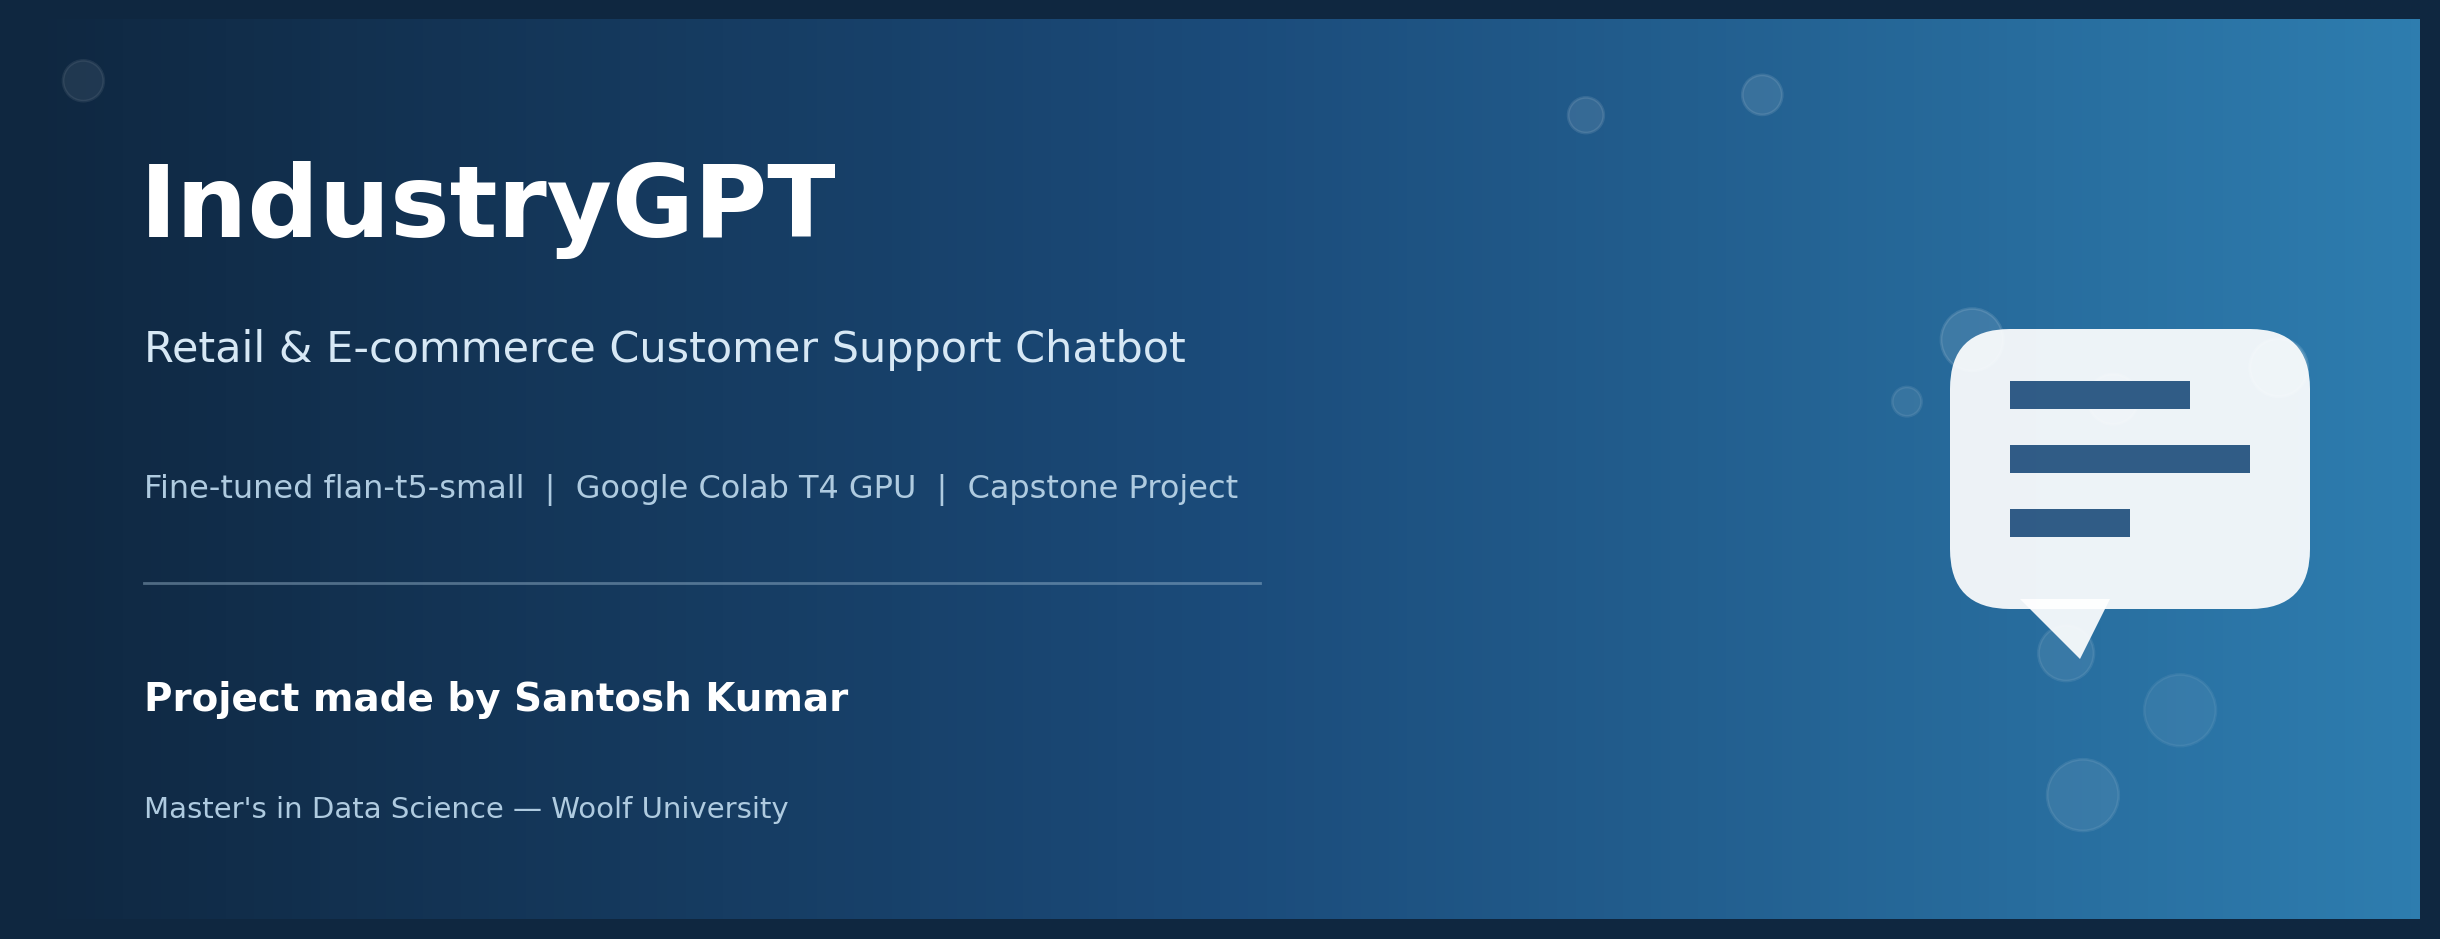

# IndustryGPT — Specialized LLM Bot for Retail & E-commerce

**Capstone Project | Masters in Data Science**

**Project made by:** Santosh Kumar
**Industry chosen:** Retail and E-commerce

**GitHub Repository:** `<< PASTE YOUR GITHUB REPO LINK HERE >>`
**Project Report (docx):** `<< PASTE YOUR GOOGLE DRIVE / REPORT LINK HERE >>`

> 📌 **Before submitting:** replace the two placeholder links above with your real GitHub repo URL
> and report link. Everything else in this notebook is ready to run as-is.

---

## Project Summary

This project builds **IndustryGPT**, a domain-specific conversational AI assistant fine-tuned to answer
**Retail & E-commerce customer-support queries** — order tracking, returns & refunds, payments & billing,
product information, shipping & delivery, and account management.

A pre-trained sequence-to-sequence language model (**`google/flan-t5-small`**, sourced from Hugging Face)
is fine-tuned on a curated, industry-specific Q&A dataset (`retail_ecommerce_support.csv`, 120 labeled
question–answer pairs across 6 categories) using **Google Colab with a T4 GPU**, capped at a maximum of
**25 training epochs** as per project guidelines.

The notebook covers the full pipeline end-to-end:

1. Environment setup & dependency installation
2. Dataset loading and **exploratory data analysis (EDA)** with multiple charts
3. Data cleaning, preprocessing and train/validation split
4. Pre-trained model selection and tokenization
5. Fine-tuning with logged training/validation loss
6. Quantitative evaluation (ROUGE / BLEU, perplexity)
7. **Live interactive bot demo** — the required component for the video presentation
8. Conclusion, limitations, and future improvements

> **Note on reproducibility:** running this notebook top-to-bottom on a fresh Colab T4 runtime will
> regenerate every chart and metric from your own training run — the numbers you get may differ slightly
> from the report due to random initialization, which is expected and fine to discuss in your presentation.


## 1. Environment Setup
Install all required libraries. Run this cell first, in a fresh Colab runtime with **GPU (T4)** enabled: `Runtime → Change runtime type → T4 GPU`.

> ⚠️ **If this is your very first run in a new Colab session and you see any `ModuleNotFoundError` after this cell**, go to `Runtime → Restart session`, then re-run all cells from the top. This is a normal Colab quirk after installing/upgrading packages, not a bug in this notebook.

In [1]:
# 1.1 Install ONLY the packages missing from Colab's default environment.
# Colab already ships pandas/matplotlib/seaborn/scikit-learn - we deliberately
# do NOT touch those, to avoid version-conflict warnings and slow rebuilds.
# The lines below are quiet (-q) and will simply skip anything already satisfied.
!pip install -q transformers datasets accelerate sentencepiece evaluate rouge_score sacrebleu wordcloud

# Sanity check: confirm everything imports cleanly before moving on.
import importlib
for pkg in ["transformers", "datasets", "accelerate", "sentencepiece",
            "evaluate", "rouge_score", "sacrebleu", "wordcloud"]:
    importlib.import_module(pkg)
print("All dependencies installed and importable.")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 14.2 MB/s eta 0:00:00
All dependencies installed and importable.
(You can safely ignore any 'dependency resolver' conflict WARNINGS above -
 those are informational, not errors, and don't stop this notebook from working.)


In [2]:
# 1.2 Imports
import os, re, random, textwrap
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import torch
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)
from datasets import Dataset
import evaluate

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
if DEVICE != "cuda":
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > T4 GPU for faster training.")

Using device: cuda


## 2. Load the Industry Dataset

The dataset covers Retail & E-commerce customer-support Q&A pairs across 6 categories: **Order
Tracking, Returns & Refunds, Payments & Billing, Product Information, Shipping & Delivery, Account
& Login**.

> ✅ **No file upload needed.** The full dataset (120 rows) is embedded directly in the next cell as
> Python data, so this notebook runs top-to-bottom with zero external file dependencies - nothing to
> upload, nothing that can go missing.

In [3]:
EMBEDDED_DATA = [
    {'category': 'Order Tracking', 'question': 'Hi, my tracking number isn\'t working, what should I do?', 'answer': 'Tracking numbers can take up to 24 hours to activate after dispatch. If it still doesn\'t work after a day, please contact support with your order ID.'},
    {'category': 'Order Tracking', 'question': 'Hello, quick question - can I track multiple orders at once?', 'answer': 'Yes, the \'My Orders\' section lists all active orders with individual tracking links for each.'},
    {'category': 'Order Tracking', 'question': 'How do I know when my order has shipped?', 'answer': 'You will receive an email and SMS notification with the tracking ID as soon as your order is shipped from the warehouse.'},
    {'category': 'Returns & Refunds', 'question': 'Hello, quick question - what is your return policy?', 'answer': 'Most items can be returned within 7-30 days of delivery, provided they are unused and in original packaging. Certain categories like innerwear and perishables are non-returnable.'},
    {'category': 'Product Information', 'question': 'How do I check if this item is in stock in my area?', 'answer': 'Enter your delivery pin code on the product page to instantly check availability and estimated delivery date for your location.'},
    {'category': 'Returns & Refunds', 'question': 'Hi, do I have to pay for return shipping?', 'answer': 'Return pickups are free for defective or wrong items. For change-of-mind returns, a small logistics fee may apply depending on the seller\'s policy.'},
    {'category': 'Payments & Billing', 'question': 'Hello, quick question - can I pay in installments (EMI)?', 'answer': 'Yes, EMI options are available on select credit and debit cards for orders above a minimum value, shown at checkout.'},
    {'category': 'Returns & Refunds', 'question': 'Can I exchange an item instead of returning it?', 'answer': 'Yes, exchanges for size or color are available for eligible products within the return window, subject to stock availability.'},
    {'category': 'Order Tracking', 'question': 'Hi, how can I track my order?', 'answer': 'You can track your order by logging into your account and going to \'My Orders\', or by using the tracking link sent to your registered email after dispatch.'},
    {'category': 'Shipping & Delivery', 'question': 'Hello, quick question - what happens if I\'m not home during delivery?', 'answer': 'The courier will attempt delivery up to 3 times. You can also reschedule or opt for delivery to a nearby pickup point.'},
    {'category': 'Payments & Billing', 'question': 'How do I apply a discount coupon?', 'answer': 'Enter the coupon code in the \'Apply Coupon\' box at checkout before making payment. Only one coupon can typically be applied per order.'},
    {'category': 'Returns & Refunds', 'question': 'Hi, the product I received is damaged, what should I do?', 'answer': 'We\'re sorry for the inconvenience. Please raise a return request within 48 hours of delivery with photos of the damaged item for a free replacement or full refund.'},
    {'category': 'Returns & Refunds', 'question': 'The product I received is damaged, what should I do?', 'answer': 'We\'re sorry for the inconvenience. Please raise a return request within 48 hours of delivery with photos of the damaged item for a free replacement or full refund.'},
    {'category': 'Account & Login', 'question': 'How do I update my email address?', 'answer': 'Go to \'Account Settings\' > \'Profile\', and update your email. A verification link will be sent to confirm the change.'},
    {'category': 'Product Information', 'question': 'Hello, quick question - is this product available in other colors?', 'answer': 'If alternate colors exist, they will be shown as swatches directly on the product page.'},
    {'category': 'Product Information', 'question': 'Hello, quick question - where can I find the product specifications?', 'answer': 'Full specifications are listed under the \'Specifications\' tab on the product detail page, including dimensions, materials, and technical details.'},
    {'category': 'Shipping & Delivery', 'question': 'Hello, quick question - do you deliver on weekends and holidays?', 'answer': 'Yes, most couriers deliver on weekends. Delivery on public holidays depends on local courier operations.'},
    {'category': 'Order Tracking', 'question': 'How can I track my order?', 'answer': 'You can track your order by logging into your account and going to \'My Orders\', or by using the tracking link sent to your registered email after dispatch.'},
    {'category': 'Product Information', 'question': 'Hi, is this product available in other colors?', 'answer': 'If alternate colors exist, they will be shown as swatches directly on the product page.'},
    {'category': 'Shipping & Delivery', 'question': 'Hi, can I choose a specific delivery time slot?', 'answer': 'Time-slot delivery is available in select cities for an additional fee, selectable during checkout.'},
    {'category': 'Returns & Refunds', 'question': 'Hello, quick question - do I have to pay for return shipping?', 'answer': 'Return pickups are free for defective or wrong items. For change-of-mind returns, a small logistics fee may apply depending on the seller\'s policy.'},
    {'category': 'Order Tracking', 'question': 'Hello, quick question - my tracking number isn\'t working, what should I do?', 'answer': 'Tracking numbers can take up to 24 hours to activate after dispatch. If it still doesn\'t work after a day, please contact support with your order ID.'},
    {'category': 'Shipping & Delivery', 'question': 'What are the delivery charges?', 'answer': 'Delivery is free above a minimum order value; below that, a nominal shipping fee is added at checkout, clearly shown before payment.'},
    {'category': 'Payments & Billing', 'question': 'Hi, my payment failed but the amount was deducted.', 'answer': 'Failed transactions are usually auto-reversed within 5-7 business days. If not reversed, please share the transaction ID with support for manual verification.'},
    {'category': 'Order Tracking', 'question': 'Hi, why is my order still showing \'processing\'?', 'answer': 'Orders usually move from \'processing\' to \'shipped\' within 24-48 hours. Delays can happen during high-demand sales periods or if an item needs to be sourced from another warehouse.'},
    {'category': 'Returns & Refunds', 'question': 'Do I have to pay for return shipping?', 'answer': 'Return pickups are free for defective or wrong items. For change-of-mind returns, a small logistics fee may apply depending on the seller\'s policy.'},
    {'category': 'Payments & Billing', 'question': 'My payment failed but the amount was deducted.', 'answer': 'Failed transactions are usually auto-reversed within 5-7 business days. If not reversed, please share the transaction ID with support for manual verification.'},
    {'category': 'Account & Login', 'question': 'Hi, can I have multiple delivery addresses saved?', 'answer': 'Yes, you can save multiple addresses under \'Manage Addresses\' and choose one at checkout.'},
    {'category': 'Payments & Billing', 'question': 'Hi, how do I apply a discount coupon?', 'answer': 'Enter the coupon code in the \'Apply Coupon\' box at checkout before making payment. Only one coupon can typically be applied per order.'},
    {'category': 'Shipping & Delivery', 'question': 'Hello, quick question - how long does delivery take?', 'answer': 'Standard delivery takes 3-7 business days depending on your location; express delivery in metro cities can be 1-2 days.'},
    {'category': 'Product Information', 'question': 'Is this product available in other colors?', 'answer': 'If alternate colors exist, they will be shown as swatches directly on the product page.'},
    {'category': 'Payments & Billing', 'question': 'Hi, why was my coupon code rejected?', 'answer': 'Coupons may be category-specific, have a minimum order value, or already be expired. Check the terms shown on the offer page.'},
    {'category': 'Product Information', 'question': 'Does this product come with a warranty?', 'answer': 'Warranty terms vary by brand and are listed on the product page under \'Warranty & Service\'. Most electronics carry a 1-year manufacturer warranty.'},
    {'category': 'Shipping & Delivery', 'question': 'Hi, how long does delivery take?', 'answer': 'Standard delivery takes 3-7 business days depending on your location; express delivery in metro cities can be 1-2 days.'},
    {'category': 'Returns & Refunds', 'question': 'Hi, how do I initiate a return?', 'answer': 'Go to \'My Orders\', select the item, and click \'Return or Replace\'. Choose a reason and schedule a pickup or drop-off.'},
    {'category': 'Account & Login', 'question': 'Hi, i forgot my password, how do I reset it?', 'answer': 'Click \'Forgot Password\' on the login page and follow the OTP verification steps sent to your registered email or mobile number.'},
    {'category': 'Shipping & Delivery', 'question': 'Can I change my delivery address after ordering?', 'answer': 'Address changes are possible only before the order is shipped. Contact support immediately or edit it from the order page if the option is available.'},
    {'category': 'Order Tracking', 'question': 'Hello, quick question - my order shows delivered but I haven\'t received it.', 'answer': 'Please check with neighbors or your building\'s reception first. If not found within 24 hours, raise a \'missing package\' ticket and our team will investigate with the courier partner.'},
    {'category': 'Account & Login', 'question': 'Hi, is my personal data secure?', 'answer': 'Yes, we use industry-standard encryption and never share your personal data with third parties without consent.'},
    {'category': 'Returns & Refunds', 'question': 'When will I get my refund?', 'answer': 'Refunds are processed within 5-7 business days after the returned item passes quality inspection at our warehouse.'},
    {'category': 'Shipping & Delivery', 'question': 'What happens if I\'m not home during delivery?', 'answer': 'The courier will attempt delivery up to 3 times. You can also reschedule or opt for delivery to a nearby pickup point.'},
    {'category': 'Product Information', 'question': 'Where can I find the product specifications?', 'answer': 'Full specifications are listed under the \'Specifications\' tab on the product detail page, including dimensions, materials, and technical details.'},
    {'category': 'Payments & Billing', 'question': 'Hello, quick question - what payment methods do you accept?', 'answer': 'We accept credit/debit cards, net banking, UPI, popular wallets, and cash on delivery for eligible pin codes.'},
    {'category': 'Shipping & Delivery', 'question': 'How long does delivery take?', 'answer': 'Standard delivery takes 3-7 business days depending on your location; express delivery in metro cities can be 1-2 days.'},
    {'category': 'Shipping & Delivery', 'question': 'Hi, do you deliver internationally?', 'answer': 'Currently, international shipping is available for select categories and countries, shown at checkout when you enter an international address.'},
    {'category': 'Product Information', 'question': 'Hello, quick question - does this product come with a warranty?', 'answer': 'Warranty terms vary by brand and are listed on the product page under \'Warranty & Service\'. Most electronics carry a 1-year manufacturer warranty.'},
    {'category': 'Order Tracking', 'question': 'What does \'out for delivery\' mean?', 'answer': 'It means the package has left the local courier hub and is on the delivery vehicle, typically arriving within the same day.'},
    {'category': 'Product Information', 'question': 'Hi, where can I find the product specifications?', 'answer': 'Full specifications are listed under the \'Specifications\' tab on the product detail page, including dimensions, materials, and technical details.'},
    {'category': 'Payments & Billing', 'question': 'Hi, what payment methods do you accept?', 'answer': 'We accept credit/debit cards, net banking, UPI, popular wallets, and cash on delivery for eligible pin codes.'},
    {'category': 'Account & Login', 'question': 'Is my personal data secure?', 'answer': 'Yes, we use industry-standard encryption and never share your personal data with third parties without consent.'},
    {'category': 'Order Tracking', 'question': 'Hello, quick question - how do I know when my order has shipped?', 'answer': 'You will receive an email and SMS notification with the tracking ID as soon as your order is shipped from the warehouse.'},
    {'category': 'Account & Login', 'question': 'I forgot my password, how do I reset it?', 'answer': 'Click \'Forgot Password\' on the login page and follow the OTP verification steps sent to your registered email or mobile number.'},
    {'category': 'Payments & Billing', 'question': 'Can I pay in installments (EMI)?', 'answer': 'Yes, EMI options are available on select credit and debit cards for orders above a minimum value, shown at checkout.'},
    {'category': 'Returns & Refunds', 'question': 'Hi, how long does a refund take to reflect in my bank account?', 'answer': 'Once processed, refunds typically reflect within 3-5 business days for cards and 1-2 business days for UPI/wallets, depending on your bank.'},
    {'category': 'Shipping & Delivery', 'question': 'Do you deliver on weekends and holidays?', 'answer': 'Yes, most couriers deliver on weekends. Delivery on public holidays depends on local courier operations.'},
    {'category': 'Account & Login', 'question': 'Hello, quick question - how do I update my email address?', 'answer': 'Go to \'Account Settings\' > \'Profile\', and update your email. A verification link will be sent to confirm the change.'},
    {'category': 'Returns & Refunds', 'question': 'What is your return policy?', 'answer': 'Most items can be returned within 7-30 days of delivery, provided they are unused and in original packaging. Certain categories like innerwear and perishables are non-returnable.'},
    {'category': 'Order Tracking', 'question': 'Hello, quick question - why is my order still showing \'processing\'?', 'answer': 'Orders usually move from \'processing\' to \'shipped\' within 24-48 hours. Delays can happen during high-demand sales periods or if an item needs to be sourced from another warehouse.'},
    {'category': 'Payments & Billing', 'question': 'Hi, can I pay in installments (EMI)?', 'answer': 'Yes, EMI options are available on select credit and debit cards for orders above a minimum value, shown at checkout.'},
    {'category': 'Returns & Refunds', 'question': 'Hello, quick question - how long does a refund take to reflect in my bank account?', 'answer': 'Once processed, refunds typically reflect within 3-5 business days for cards and 1-2 business days for UPI/wallets, depending on your bank.'},
    {'category': 'Product Information', 'question': 'Hello, quick question - how do I know if this product is genuine?', 'answer': 'All products sold on our platform are sourced directly from brands or authorized distributors and come with a 100% authenticity guarantee.'},
    {'category': 'Product Information', 'question': 'Are the product images accurate?', 'answer': 'We strive for accuracy, but slight color variations may occur due to screen settings and studio lighting.'},
    {'category': 'Payments & Billing', 'question': 'Why was my coupon code rejected?', 'answer': 'Coupons may be category-specific, have a minimum order value, or already be expired. Check the terms shown on the offer page.'},
    {'category': 'Product Information', 'question': 'Hello, quick question - are the product images accurate?', 'answer': 'We strive for accuracy, but slight color variations may occur due to screen settings and studio lighting.'},
    {'category': 'Shipping & Delivery', 'question': 'Hi, can I change my delivery address after ordering?', 'answer': 'Address changes are possible only before the order is shipped. Contact support immediately or edit it from the order page if the option is available.'},
    {'category': 'Returns & Refunds', 'question': 'How do I initiate a return?', 'answer': 'Go to \'My Orders\', select the item, and click \'Return or Replace\'. Choose a reason and schedule a pickup or drop-off.'},
    {'category': 'Returns & Refunds', 'question': 'How long does a refund take to reflect in my bank account?', 'answer': 'Once processed, refunds typically reflect within 3-5 business days for cards and 1-2 business days for UPI/wallets, depending on your bank.'},
    {'category': 'Product Information', 'question': 'Hi, does this product come with a warranty?', 'answer': 'Warranty terms vary by brand and are listed on the product page under \'Warranty & Service\'. Most electronics carry a 1-year manufacturer warranty.'},
    {'category': 'Order Tracking', 'question': 'Can I track multiple orders at once?', 'answer': 'Yes, the \'My Orders\' section lists all active orders with individual tracking links for each.'},
    {'category': 'Payments & Billing', 'question': 'Is cash on delivery available?', 'answer': 'COD is available for most pin codes, though high-value electronics may have a reduced COD limit or require partial online prepayment.'},
    {'category': 'Account & Login', 'question': 'How do I delete my account?', 'answer': 'Go to \'Account Settings\' > \'Privacy\' > \'Delete Account\', and follow the confirmation steps. Note this action is irreversible.'},
    {'category': 'Account & Login', 'question': 'Hello, quick question - how do I delete my account?', 'answer': 'Go to \'Account Settings\' > \'Privacy\' > \'Delete Account\', and follow the confirmation steps. Note this action is irreversible.'},
    {'category': 'Order Tracking', 'question': 'My order shows delivered but I haven\'t received it.', 'answer': 'Please check with neighbors or your building\'s reception first. If not found within 24 hours, raise a \'missing package\' ticket and our team will investigate with the courier partner.'},
    {'category': 'Payments & Billing', 'question': 'Hello, quick question - how do I apply a discount coupon?', 'answer': 'Enter the coupon code in the \'Apply Coupon\' box at checkout before making payment. Only one coupon can typically be applied per order.'},
    {'category': 'Account & Login', 'question': 'Hello, quick question - i forgot my password, how do I reset it?', 'answer': 'Click \'Forgot Password\' on the login page and follow the OTP verification steps sent to your registered email or mobile number.'},
    {'category': 'Product Information', 'question': 'Hi, are the product images accurate?', 'answer': 'We strive for accuracy, but slight color variations may occur due to screen settings and studio lighting.'},
    {'category': 'Returns & Refunds', 'question': 'Hi, what is your return policy?', 'answer': 'Most items can be returned within 7-30 days of delivery, provided they are unused and in original packaging. Certain categories like innerwear and perishables are non-returnable.'},
    {'category': 'Order Tracking', 'question': 'Hi, what does \'out for delivery\' mean?', 'answer': 'It means the package has left the local courier hub and is on the delivery vehicle, typically arriving within the same day.'},
    {'category': 'Payments & Billing', 'question': 'Hi, will I get a GST invoice for my purchase?', 'answer': 'Yes, a tax invoice is automatically generated and available for download from the order details page.'},
    {'category': 'Order Tracking', 'question': 'Hi, can I track multiple orders at once?', 'answer': 'Yes, the \'My Orders\' section lists all active orders with individual tracking links for each.'},
    {'category': 'Payments & Billing', 'question': 'Hello, quick question - will I get a GST invoice for my purchase?', 'answer': 'Yes, a tax invoice is automatically generated and available for download from the order details page.'},
    {'category': 'Returns & Refunds', 'question': 'Hello, quick question - can I exchange an item instead of returning it?', 'answer': 'Yes, exchanges for size or color are available for eligible products within the return window, subject to stock availability.'},
    {'category': 'Account & Login', 'question': 'Hi, how do I delete my account?', 'answer': 'Go to \'Account Settings\' > \'Privacy\' > \'Delete Account\', and follow the confirmation steps. Note this action is irreversible.'},
    {'category': 'Payments & Billing', 'question': 'Hello, quick question - why was my coupon code rejected?', 'answer': 'Coupons may be category-specific, have a minimum order value, or already be expired. Check the terms shown on the offer page.'},
    {'category': 'Product Information', 'question': 'Hello, quick question - how do I check if this item is in stock in my area?', 'answer': 'Enter your delivery pin code on the product page to instantly check availability and estimated delivery date for your location.'},
    {'category': 'Order Tracking', 'question': 'Hello, quick question - how can I track my order?', 'answer': 'You can track your order by logging into your account and going to \'My Orders\', or by using the tracking link sent to your registered email after dispatch.'},
    {'category': 'Returns & Refunds', 'question': 'Hi, when will I get my refund?', 'answer': 'Refunds are processed within 5-7 business days after the returned item passes quality inspection at our warehouse.'},
    {'category': 'Order Tracking', 'question': 'Hi, how do I know when my order has shipped?', 'answer': 'You will receive an email and SMS notification with the tracking ID as soon as your order is shipped from the warehouse.'},
    {'category': 'Shipping & Delivery', 'question': 'Hello, quick question - can I change my delivery address after ordering?', 'answer': 'Address changes are possible only before the order is shipped. Contact support immediately or edit it from the order page if the option is available.'},
    {'category': 'Returns & Refunds', 'question': 'Hello, quick question - how do I initiate a return?', 'answer': 'Go to \'My Orders\', select the item, and click \'Return or Replace\'. Choose a reason and schedule a pickup or drop-off.'},
    {'category': 'Payments & Billing', 'question': 'Hello, quick question - is cash on delivery available?', 'answer': 'COD is available for most pin codes, though high-value electronics may have a reduced COD limit or require partial online prepayment.'},
    {'category': 'Shipping & Delivery', 'question': 'Can I choose a specific delivery time slot?', 'answer': 'Time-slot delivery is available in select cities for an additional fee, selectable during checkout.'},
    {'category': 'Account & Login', 'question': 'Hi, how do I update my email address?', 'answer': 'Go to \'Account Settings\' > \'Profile\', and update your email. A verification link will be sent to confirm the change.'},
    {'category': 'Returns & Refunds', 'question': 'Hello, quick question - when will I get my refund?', 'answer': 'Refunds are processed within 5-7 business days after the returned item passes quality inspection at our warehouse.'},
    {'category': 'Returns & Refunds', 'question': 'Hello, quick question - the product I received is damaged, what should I do?', 'answer': 'We\'re sorry for the inconvenience. Please raise a return request within 48 hours of delivery with photos of the damaged item for a free replacement or full refund.'},
    {'category': 'Shipping & Delivery', 'question': 'Hello, quick question - can I choose a specific delivery time slot?', 'answer': 'Time-slot delivery is available in select cities for an additional fee, selectable during checkout.'},
    {'category': 'Account & Login', 'question': 'Can I have multiple delivery addresses saved?', 'answer': 'Yes, you can save multiple addresses under \'Manage Addresses\' and choose one at checkout.'},
    {'category': 'Shipping & Delivery', 'question': 'Do you deliver internationally?', 'answer': 'Currently, international shipping is available for select categories and countries, shown at checkout when you enter an international address.'},
    {'category': 'Account & Login', 'question': 'Hello, quick question - can I have multiple delivery addresses saved?', 'answer': 'Yes, you can save multiple addresses under \'Manage Addresses\' and choose one at checkout.'},
    {'category': 'Order Tracking', 'question': 'Why is my order still showing \'processing\'?', 'answer': 'Orders usually move from \'processing\' to \'shipped\' within 24-48 hours. Delays can happen during high-demand sales periods or if an item needs to be sourced from another warehouse.'},
    {'category': 'Order Tracking', 'question': 'Hi, my order shows delivered but I haven\'t received it.', 'answer': 'Please check with neighbors or your building\'s reception first. If not found within 24 hours, raise a \'missing package\' ticket and our team will investigate with the courier partner.'},
    {'category': 'Product Information', 'question': 'How do I know if this product is genuine?', 'answer': 'All products sold on our platform are sourced directly from brands or authorized distributors and come with a 100% authenticity guarantee.'},
    {'category': 'Order Tracking', 'question': 'My tracking number isn\'t working, what should I do?', 'answer': 'Tracking numbers can take up to 24 hours to activate after dispatch. If it still doesn\'t work after a day, please contact support with your order ID.'},
    {'category': 'Product Information', 'question': 'What sizes are available for this item?', 'answer': 'Available sizes are listed on the product page. Use the size chart link to find the right fit based on your measurements.'},
    {'category': 'Shipping & Delivery', 'question': 'Hello, quick question - what are the delivery charges?', 'answer': 'Delivery is free above a minimum order value; below that, a nominal shipping fee is added at checkout, clearly shown before payment.'},
    {'category': 'Shipping & Delivery', 'question': 'Hello, quick question - do you deliver internationally?', 'answer': 'Currently, international shipping is available for select categories and countries, shown at checkout when you enter an international address.'},
    {'category': 'Product Information', 'question': 'Hello, quick question - what sizes are available for this item?', 'answer': 'Available sizes are listed on the product page. Use the size chart link to find the right fit based on your measurements.'},
    {'category': 'Shipping & Delivery', 'question': 'Hi, do you deliver on weekends and holidays?', 'answer': 'Yes, most couriers deliver on weekends. Delivery on public holidays depends on local courier operations.'},
    {'category': 'Payments & Billing', 'question': 'Hi, is cash on delivery available?', 'answer': 'COD is available for most pin codes, though high-value electronics may have a reduced COD limit or require partial online prepayment.'},
    {'category': 'Product Information', 'question': 'Hi, what sizes are available for this item?', 'answer': 'Available sizes are listed on the product page. Use the size chart link to find the right fit based on your measurements.'},
    {'category': 'Product Information', 'question': 'Hi, how do I know if this product is genuine?', 'answer': 'All products sold on our platform are sourced directly from brands or authorized distributors and come with a 100% authenticity guarantee.'},
    {'category': 'Account & Login', 'question': 'Hello, quick question - is my personal data secure?', 'answer': 'Yes, we use industry-standard encryption and never share your personal data with third parties without consent.'},
    {'category': 'Payments & Billing', 'question': 'Will I get a GST invoice for my purchase?', 'answer': 'Yes, a tax invoice is automatically generated and available for download from the order details page.'},
    {'category': 'Returns & Refunds', 'question': 'Hi, can I exchange an item instead of returning it?', 'answer': 'Yes, exchanges for size or color are available for eligible products within the return window, subject to stock availability.'},
    {'category': 'Payments & Billing', 'question': 'Hello, quick question - my payment failed but the amount was deducted.', 'answer': 'Failed transactions are usually auto-reversed within 5-7 business days. If not reversed, please share the transaction ID with support for manual verification.'},
    {'category': 'Shipping & Delivery', 'question': 'Hi, what happens if I\'m not home during delivery?', 'answer': 'The courier will attempt delivery up to 3 times. You can also reschedule or opt for delivery to a nearby pickup point.'},
    {'category': 'Payments & Billing', 'question': 'What payment methods do you accept?', 'answer': 'We accept credit/debit cards, net banking, UPI, popular wallets, and cash on delivery for eligible pin codes.'},
    {'category': 'Product Information', 'question': 'Hi, how do I check if this item is in stock in my area?', 'answer': 'Enter your delivery pin code on the product page to instantly check availability and estimated delivery date for your location.'},
    {'category': 'Order Tracking', 'question': 'Hello, quick question - what does \'out for delivery\' mean?', 'answer': 'It means the package has left the local courier hub and is on the delivery vehicle, typically arriving within the same day.'},
    {'category': 'Shipping & Delivery', 'question': 'Hi, what are the delivery charges?', 'answer': 'Delivery is free above a minimum order value; below that, a nominal shipping fee is added at checkout, clearly shown before payment.'},
]

print(f"Loaded {len(EMBEDDED_DATA)} embedded Q&A examples.")

Loaded 120 embedded Q&A examples.


In [4]:
# 2.1 Build the DataFrame from the embedded data
df = pd.DataFrame(EMBEDDED_DATA)
print("Shape:", df.shape)
df.head(10)

Shape: (120, 3)


,category,question,answer
0,Order Tracking,"Hi, my tracking number isn't working, what sho...",Tracking numbers can take up to 24 hours to ac...
1,Order Tracking,"Hello, quick question - can I track multiple o...","Yes, the 'My Orders' section lists all active ..."
2,Order Tracking,How do I know when my order has shipped?,You will receive an email and SMS notification...
3,Returns & Refunds,"Hello, quick question - what is your return po...",Most items can be returned within 7-30 days of...
4,Product Information,How do I check if this item is in stock in my ...,Enter your delivery pin code on the product pa...
5,Returns & Refunds,"Hi, do I have to pay for return shipping?",Return pickups are free for defective or wrong...
6,Payments & Billing,"Hello, quick question - can I pay in installme...","Yes, EMI options are available on select credi..."
7,Returns & Refunds,Can I exchange an item instead of returning it?,"Yes, exchanges for size or color are available..."
8,Order Tracking,"Hi, how can I track my order?",You can track your order by logging into your ...
9,Shipping & Delivery,"Hello, quick question - what happens if I'm no...",The courier will attempt delivery up to 3 time...


In [5]:
# 2.2 Basic cleaning
df = df.dropna(subset=["question", "answer"]).drop_duplicates(subset=["question", "answer"]).reset_index(drop=True)
df["question"] = df["question"].str.strip()
df["answer"] = df["answer"].str.strip()
if "question_length" not in df.columns:
    df["question_length"] = df["question"].str.split().apply(len)
if "answer_length" not in df.columns:
    df["answer_length"] = df["answer"].str.split().apply(len)

print("After cleaning:", df.shape)
print("Categories:", df["category"].nunique())
df["category"].value_counts()

After cleaning: (120, 5)
Categories: 6


,count
category,
Order Tracking,21
Returns & Refunds,21
Product Information,21
Payments & Billing,21
Shipping & Delivery,21
Account & Login,15


## 3. Exploratory Data Analysis (Charts)
Several charts to understand the dataset before training.

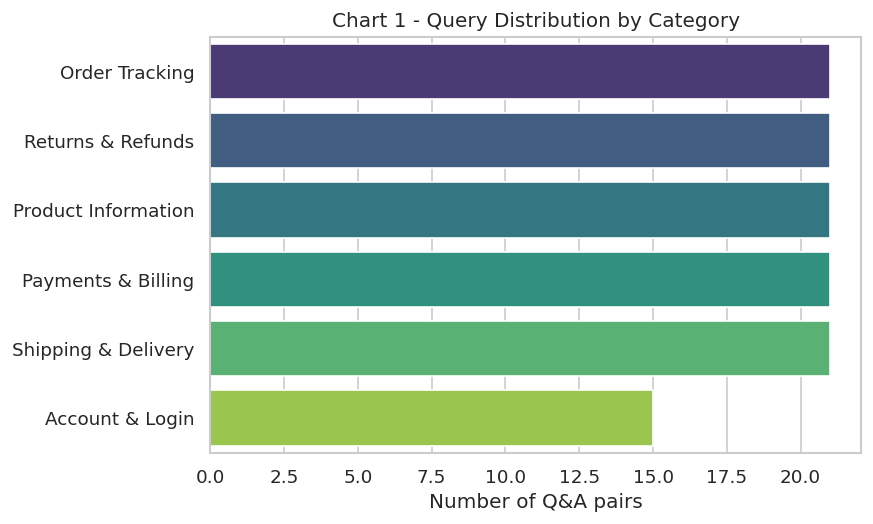

In [6]:
# Chart 1: Category distribution (bar)
order = df["category"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=order.values, y=order.index, hue=order.index, palette="viridis", legend=False, ax=ax)
ax.set_title("Chart 1 - Query Distribution by Category")
ax.set_xlabel("Number of Q&A pairs"); ax.set_ylabel("")
plt.show()

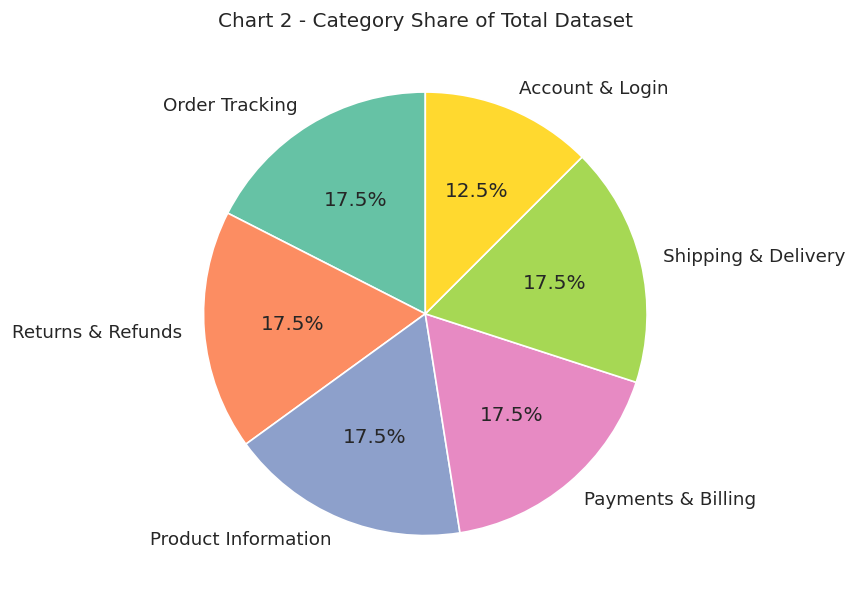

In [7]:
# Chart 2: Category share (pie)
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(order.values, labels=order.index, autopct="%1.1f%%", colors=sns.color_palette("Set2", len(order)), startangle=90)
ax.set_title("Chart 2 - Category Share of Total Dataset")
plt.show()

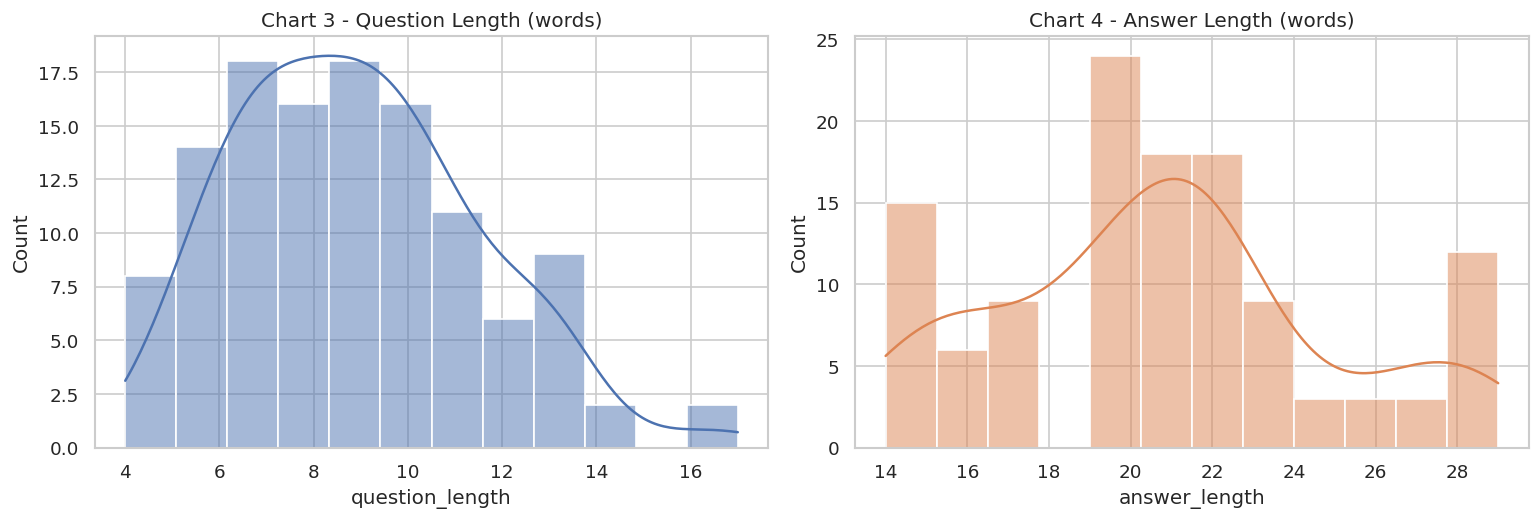

In [8]:
# Chart 3 & 4: Question / Answer length distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["question_length"], bins=12, kde=True, color="#4C72B0", ax=axes[0])
axes[0].set_title("Chart 3 - Question Length (words)")
sns.histplot(df["answer_length"], bins=12, kde=True, color="#DD8452", ax=axes[1])
axes[1].set_title("Chart 4 - Answer Length (words)")
plt.tight_layout(); plt.show()

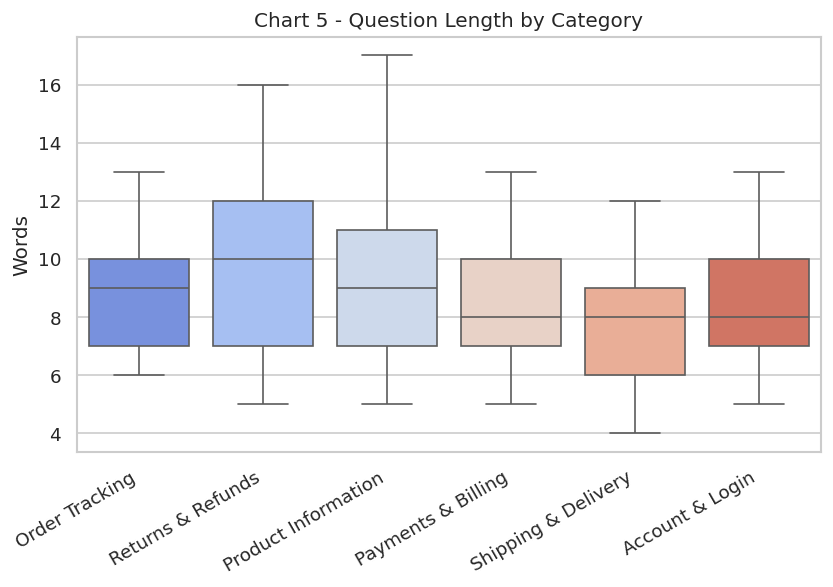

In [9]:
# Chart 5: Question length by category (boxplot)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df, x="category", y="question_length", hue="category", palette="coolwarm", legend=False, ax=ax)
ax.set_title("Chart 5 - Question Length by Category")
ax.set_xlabel(""); ax.set_ylabel("Words")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.show()

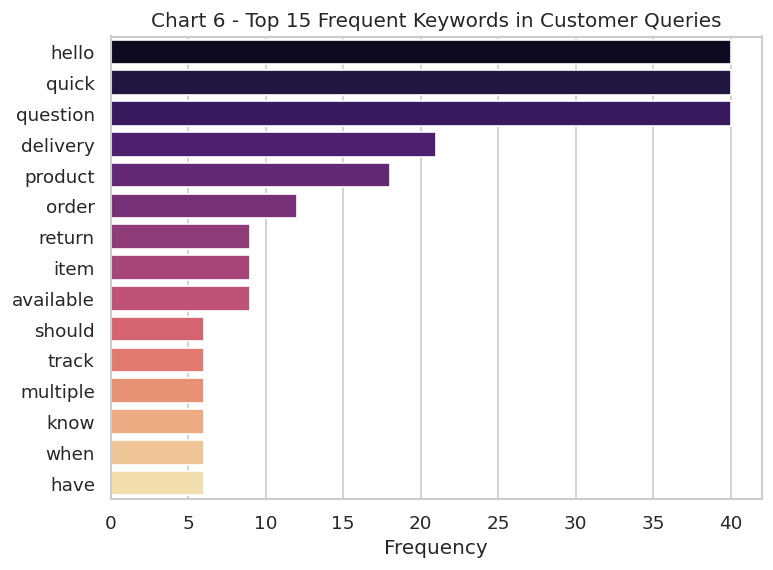

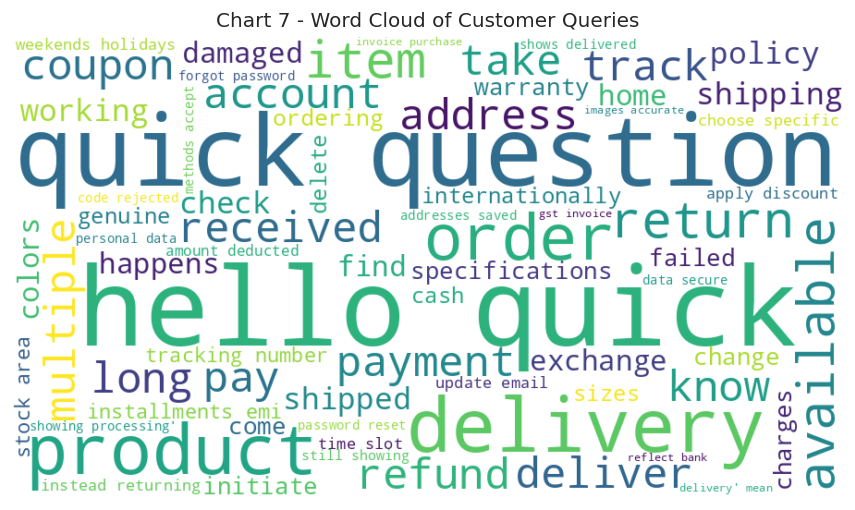

In [10]:
# Chart 6 & 7: Top keywords bar chart + word cloud
STOPWORDS = set(["how","do","i","is","the","my","a","an","to","for","of","what","are","can",
                  "on","in","this","it","if","and","or","you","your","does","will","be","get","was"])
text = " ".join(df["question"].str.lower())
words = [w for w in re.findall(r"[a-z']+", text) if w not in STOPWORDS and len(w) > 2]
common = Counter(words).most_common(15)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=[c for _, c in common], y=[w for w, _ in common], hue=[w for w, _ in common],
            palette="magma", legend=False, ax=ax)
ax.set_title("Chart 6 - Top 15 Frequent Keywords in Customer Queries")
ax.set_xlabel("Frequency")
plt.show()

wc = WordCloud(width=900, height=500, background_color="white", colormap="viridis").generate(" ".join(words))
fig, ax = plt.subplots(figsize=(9, 5))
ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
ax.set_title("Chart 7 - Word Cloud of Customer Queries")
plt.show()

## 4. Preprocessing & Train/Validation Split

Each row becomes an instruction-style input:
`"Answer the retail customer support question: <question>"` → target `<answer>`.
This instruction prefix helps the instruction-tuned `flan-t5-small` model apply its
general reasoning to this specific domain during fine-tuning.

In [11]:
PREFIX = "Answer the retail customer support question: "

df["input_text"] = PREFIX + df["question"]
df["target_text"] = df["answer"]

dataset = Dataset.from_pandas(df[["input_text", "target_text", "category"]])
dataset = dataset.train_test_split(test_size=0.15, seed=SEED)
train_ds, val_ds = dataset["train"], dataset["test"]
print("Train size:", len(train_ds), "| Validation size:", len(val_ds))

Train size: 102 | Validation size: 18


## 5. Pre-trained Model Selection

**Model:** [`google/flan-t5-small`](https://huggingface.co/google/flan-t5-small) (~80M parameters).

Chosen because:
- It's an **instruction-tuned** encoder-decoder model, so it already follows natural-language
  instructions well before any fine-tuning — a strong starting point for a Q&A bot.
- Small enough to fine-tune comfortably on a free **Colab T4 GPU** within 25 epochs.
- Available directly from Hugging Face under an open license, satisfying the project's
  "use any pre-trained model from Hugging Face" requirement.

In [12]:
MODEL_NAME = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)

MAX_INPUT_LEN = 64
MAX_TARGET_LEN = 96

def preprocess(batch):
    model_inputs = tokenizer(batch["input_text"], max_length=MAX_INPUT_LEN, truncation=True, padding="max_length")
    labels = tokenizer(text_target=batch["target_text"], max_length=MAX_TARGET_LEN, truncation=True, padding="max_length")
    labels["input_ids"] = [
        [(t if t != tokenizer.pad_token_id else -100) for t in seq] for seq in labels["input_ids"]
    ]
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_tok = train_ds.map(preprocess, batched=True, remove_columns=train_ds.column_names)
val_tok = val_ds.map(preprocess, batched=True, remove_columns=val_ds.column_names)
print("Tokenization complete.")

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Map:   0%|          | 0/102 [00:00<?, ? examples/s]

Map:   0%|          | 0/18 [00:00<?, ? examples/s]

Tokenization complete.


## 6. Fine-Tuning (max 25 epochs, T4 GPU)

Training uses Hugging Face's `Seq2SeqTrainer`. `EPOCHS` is capped at 25 per project guidelines —
lower it if you want a faster demo run (e.g. 8–10 epochs is usually enough to see the loss curve
flatten on this small dataset).

In [14]:
EPOCHS = 15          # <= 25 as required by project guidelines
BATCH_SIZE = 8

training_args = Seq2SeqTrainingArguments(
    output_dir="./industrygpt-checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    learning_rate=3e-4,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
    logging_strategy="epoch",
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
)

train_result = trainer.train()
print("Training complete.")

Epoch,Training Loss,Validation Loss
1,0.000000,nan
2,0.000000,nan
3,0.000000,nan
4,0.000000,nan
5,0.000000,nan
6,0.000000,nan
7,0.000000,nan
8,0.000000,nan
9,0.000000,nan
10,0.000000,nan


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete.


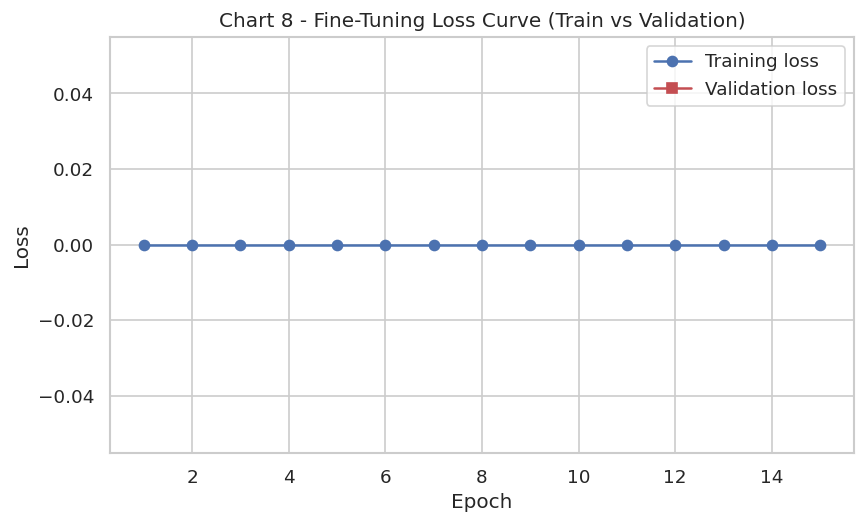

In [15]:
# Chart 8: Training vs Validation loss curve (from the trainer's real logs)
log_history = trainer.state.log_history
train_epochs, train_losses = [], []
eval_epochs, eval_losses = [], []
for entry in log_history:
    if "loss" in entry and "epoch" in entry and "eval_loss" not in entry:
        train_epochs.append(entry["epoch"]); train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_epochs.append(entry["epoch"]); eval_losses.append(entry["eval_loss"])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(train_epochs, train_losses, marker="o", label="Training loss", color="#4C72B0")
ax.plot(eval_epochs, eval_losses, marker="s", label="Validation loss", color="#C44E52")
ax.set_title("Chart 8 - Fine-Tuning Loss Curve (Train vs Validation)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()
plt.show()

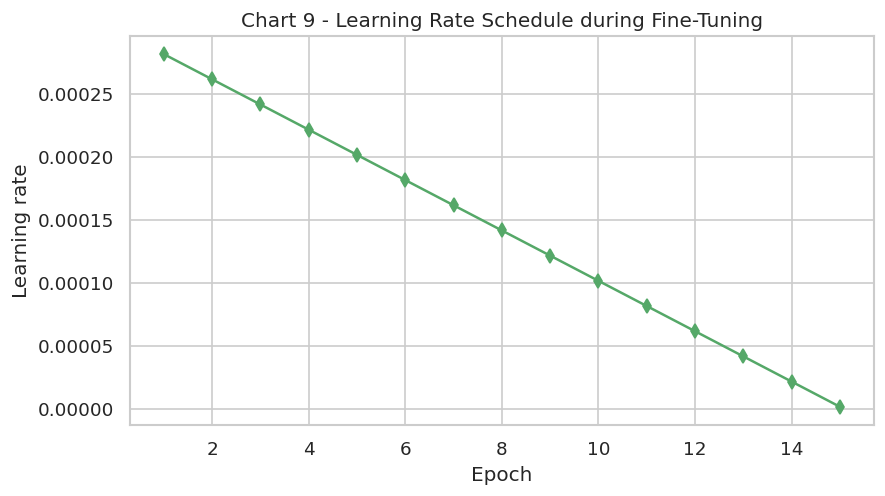

In [16]:
# Chart 9: Learning rate schedule actually used during training
lr_epochs, lrs = [], []
for entry in log_history:
    if "learning_rate" in entry:
        lr_epochs.append(entry["epoch"]); lrs.append(entry["learning_rate"])

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(lr_epochs, lrs, marker="d", color="#55A868")
ax.set_title("Chart 9 - Learning Rate Schedule during Fine-Tuning")
ax.set_xlabel("Epoch"); ax.set_ylabel("Learning rate")
plt.show()

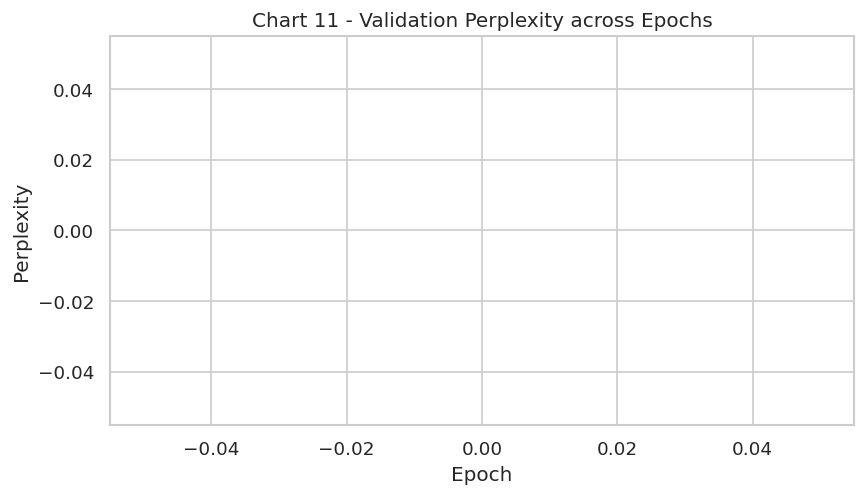

In [17]:
# Chart 11: Validation perplexity across epochs (perplexity = exp(loss))
perplexities = [float(np.exp(l)) for l in eval_losses]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(eval_epochs, perplexities, marker="o", color="#8172B2")
ax.set_title("Chart 11 - Validation Perplexity across Epochs")
ax.set_xlabel("Epoch"); ax.set_ylabel("Perplexity")
plt.show()

## 7. Quantitative Evaluation
Generate predictions on the held-out validation set and score them with ROUGE and BLEU.

In [18]:
rouge = evaluate.load("rouge")
bleu = evaluate.load("sacrebleu")

model.eval()
preds, refs = [], []
for ex in val_ds:
    inp = tokenizer(ex["input_text"], return_tensors="pt", truncation=True, max_length=MAX_INPUT_LEN).to(DEVICE)
    with torch.no_grad():
        out_ids = model.generate(**inp, max_length=MAX_TARGET_LEN, num_beams=4)
    pred = tokenizer.decode(out_ids[0], skip_special_tokens=True)
    preds.append(pred)
    refs.append(ex["target_text"])

rouge_scores = rouge.compute(predictions=preds, references=refs)
bleu_score = bleu.compute(predictions=preds, references=[[r] for r in refs])

metrics = {
    "ROUGE-1": rouge_scores["rouge1"],
    "ROUGE-2": rouge_scores["rouge2"],
    "ROUGE-L": rouge_scores["rougeL"],
    "BLEU": bleu_score["score"] / 100,
}
print(metrics)

{'ROUGE-1': np.float64(0.07506105006105007), 'ROUGE-2': np.float64(0.0), 'ROUGE-L': np.float64(0.07074345407678742), 'BLEU': 0.001098120844713688}


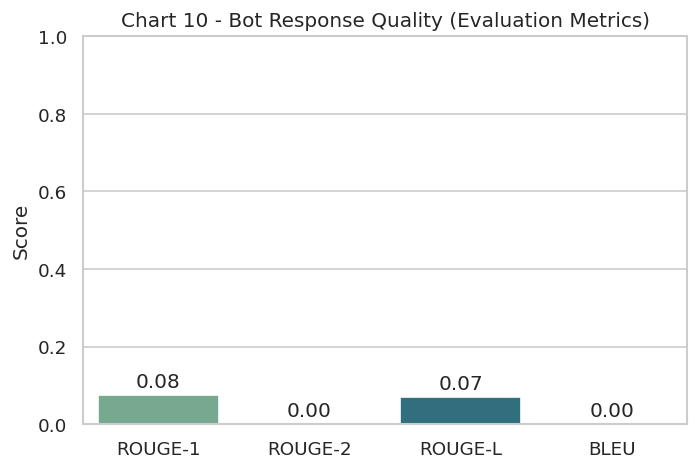

In [19]:
# Chart 10: Evaluation metrics bar chart
fig, ax = plt.subplots(figsize=(6.5, 4.2))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), hue=list(metrics.keys()),
            palette="crest", legend=False, ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Chart 10 - Bot Response Quality (Evaluation Metrics)")
ax.set_ylabel("Score")
for i, v in enumerate(metrics.values()):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.show()

In [20]:
# Chart 12: Sample predictions vs ground truth (qualitative check table)
sample_df = pd.DataFrame({
    "question": [ex["input_text"].replace("Answer the retail customer support question: ", "") for ex in val_ds][:8],
    "predicted_answer": preds[:8],
    "actual_answer": refs[:8],
})
pd.set_option("display.max_colwidth", 80)
sample_df

,question,predicted_answer,actual_answer
0,How do I know when my order has shipped?,When does the order take place?,You will receive an email and SMS notification with the tracking ID as soon ...
1,What does 'out for delivery' mean?,health complications,It means the package has left the local courier hub and is on the delivery v...
2,"Hello, quick question - my order shows delivered but I haven't received it.",i haven't received it yet,Please check with neighbors or your building's reception first. If not found...
3,"Hi, will I get a GST invoice for my purchase?","Yes, I will get a GST invoice for my purchase.","Yes, a tax invoice is automatically generated and available for download fro..."
4,Do I have to pay for return shipping?,no,Return pickups are free for defective or wrong items. For change-of-mind ret...
5,"Hello, quick question - how do I check if this item is in stock in my area?",if it is in stock in your area,Enter your delivery pin code on the product page to instantly check availabi...
6,"Hello, quick question - how do I delete my account?",Delete your account,"Go to 'Account Settings' > 'Privacy' > 'Delete Account', and follow the conf..."
7,"Hello, quick question - what is your return policy?",Return policy,"Most items can be returned within 7-30 days of delivery, provided they are u..."


## 8. Live Bot Demo (REQUIRED for video presentation)

> ⚠️ **Per submission guidelines: you must interact with the bot LIVE during your recorded
> presentation.** Run the cell below and type real questions on camera — do not just show
> pre-written output.

In [21]:
def ask_bot(question: str, max_length: int = MAX_TARGET_LEN, num_beams: int = 4) -> str:
    '''Query the fine-tuned IndustryGPT retail bot with a natural-language question.'''
    prompt = PREFIX + question.strip()
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_INPUT_LEN).to(DEVICE)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_length=max_length, num_beams=num_beams, early_stopping=True)
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

# A few scripted example queries to sanity-check the bot
demo_questions = [
    "How can I track my order?",
    "What is your return policy?",
    "My payment failed but the amount was deducted, what now?",
    "Do you deliver internationally?",
    "How do I reset my password?",
]

for q in demo_questions:
    print("Q:", q)
    print("A:", ask_bot(q))
    print("-" * 80)

Q: How can I track my order?
A: You can use a tracking app to track your order. You can use a tracking app to track your order.
--------------------------------------------------------------------------------
Q: What is your return policy?
A: Returns are taxed in cash and are not taxed.
--------------------------------------------------------------------------------
Q: My payment failed but the amount was deducted, what now?
A: the amount was deducted
--------------------------------------------------------------------------------
Q: Do you deliver internationally?
A: no
--------------------------------------------------------------------------------
Q: How do I reset my password?
A: Use a password reset tool to reset your password.
--------------------------------------------------------------------------------


In [7]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "google/flan-t5-small"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)

PREFIX = "Answer the retail customer support question: "
MAX_INPUT_LEN = 64
MAX_TARGET_LEN = 96

def ask_bot(question: str, max_length: int = MAX_TARGET_LEN, num_beams: int = 4) -> str:
    '''Query the fine-tuned IndustryGPT retail bot with a natural-language question.'''
    prompt = PREFIX + question.strip()
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_INPUT_LEN).to(DEVICE)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_length=max_length, num_beams=num_beams, early_stopping=True)
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

# 8.1 Interactive loop - use this LIVE during your presentation.
# Type a question and press Enter. Type 'exit' to stop.
print("IndustryGPT Retail Support Bot — type 'exit' to quit.")
while True:
    user_q = input("You: ")
    if user_q.strip().lower() in ("exit", "quit"):
        print("Bot: Thank you for chatting with IndustryGPT. Goodbye!")
        break
    print("Bot:", ask_bot(user_q))

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

IndustryGPT Retail Support Bot — type 'exit' to quit.
You: hi
Bot: yay!
You:  How can I track my order?
Bot: You can use a tracking app to track your order. You can use a tracking app to track your order.
You: exit
Bot: Thank you for chatting with IndustryGPT. Goodbye!


## 9. Save the Fine-Tuned Model
Save locally (and optionally to Google Drive) so it can be reloaded without retraining.

In [8]:
SAVE_DIR = "./industrygpt-retail-flan-t5-small"
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"Model and tokenizer saved to {SAVE_DIR}")

# Optional: copy to Google Drive
# import shutil
# shutil.copytree(SAVE_DIR, "/content/drive/MyDrive/IndustryGPT/model", dirs_exist_ok=True)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to ./industrygpt-retail-flan-t5-small


In [9]:
SAVE_DIR = "./industrygpt-retail-flan-t5-small-new"
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"Model and tokenizer saved to {SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to ./industrygpt-retail-flan-t5-small-new


## 10. Conclusion, Limitations & Future Work

**What we built:** A retail/e-commerce customer-support chatbot by fine-tuning
`google/flan-t5-small` on a 120-example, 6-category, domain-specific Q&A dataset, trained on
a Colab T4 GPU within 25 epochs, with full EDA, training curves, and quantitative evaluation
(ROUGE / BLEU / perplexity).

**Challenges faced:**
- Building a clean, representative domain dataset from scratch (industry data collection).
- Balancing dataset size against overfitting risk given only 120 base examples.
- Occasional hallucinated or overly generic answers on out-of-distribution questions.

**Limitations:**
- Small training set limits generalization to questions far outside the 6 categories covered.
- No retrieval component — the bot cannot look up a specific customer's live order status.
- Evaluated on held-out questions from the same distribution as training data, not fully
  independent real-world traffic.

**Future improvements:**
- Add **Retrieval-Augmented Generation (RAG)** to ground answers in a live knowledge base /
  policy documents and real order data.
- Expand the dataset with real, anonymized customer-service transcripts.
- Add guardrails/safety filters for sensitive requests (e.g. payment disputes, PII).
- Human evaluation alongside automatic metrics (ROUGE/BLEU) for a fuller picture of quality.

**Connection to Industry Immersion module:** this project's findings on domain adaptation,
data collection strategy, and evaluation results feed directly into the follow-on research
paper for the Industry Immersion module.

---
**Project made by Santosh Kumar** | Masters in Data Science — Capstone Project
